# Example 2 — readout: demodulating a tone on `adc_14`

This notebook runs a **readout operation** in co-simulation. A real cosine is injected on physical
**ADC 14** — qubit core 0's readout ADC (the response a resonator would return) — and the readout
program written below tunes the demodulator's local oscillator (LO) to the **same frequency**. The
decoder mixes the ADC samples against the LO and integrates over a window; the integrated I/Q is read
back over AXI.

The key point: **the demod frequency must match the ADC-input frequency.** When they match, the demod
product carries a DC term whose integral is large; when they differ, it averages to ~0. We plot the
ADC input and the demod signal, and check the integral against the hardware result.

> Same example DUT as notebook 1 (`CosimExampleGen`, core 0 on DAC 0 / ADC 14). The decoder's internal
> demod product is not a top-level port, so we reconstruct it in software with the *exact* LO
> convention the hardware uses and validate it against the hardware's integrated read-back.

In [1]:
%matplotlib inline
import os, sys
# locate software/python (the riscq package) by walking up from the notebook's directory
_root = os.path.abspath("")
while _root != "/" and not os.path.isdir(os.path.join(_root, "software", "python", "riscq")):
    _root = os.path.dirname(_root)
sys.path.insert(0, os.path.join(_root, "software", "python"))

import numpy as np
import matplotlib.pyplot as plt
from riscq import Program, pulse
from riscq.socconfig import default_config
from riscq.cosim import build, runner

cfg = default_config(qubit_num=2)            # the 2-qubit example DUT (core 0 on DAC 0 / ADC 14)
WORK = build.EXAMPLE_BUILD_DIR
os.makedirs(WORK, exist_ok=True)
print("riscq:", os.path.dirname(build.__file__))
print("fs =", cfg.fs / 1e9, "GSPS,  batch_size =", cfg.batch_size)

riscq: /config/build/agentic-rv-dev/software/python/riscq/cosim
fs = 8.0 GSPS,  batch_size = 16


## The readout program

Tune the demod LO to `F_READOUT`, arm one integration window, then read `res`/`real`/`imag` (the `res`
read halts the core until the integral settles) and leave them for the host. No drive pulse is played
— the ADC stimulus is injected open-loop by the harness.

In [2]:
# ---- the readout program: demodulate a tone on adc_14 at a matched frequency ----
F_READOUT = 250e6     # demod LO frequency == injected ADC-tone frequency (the matched case)
F_DETUNED = 1.5e9     # a clearly different LO, for the software detuned comparison in the plot
ADC_AMP   = 0.85      # injected ADC-tone amplitude (fraction of full scale)
DUR       = 128e-9    # integration window length (= 64 batches)
LEAD      = 96

prog = Program(cfg, lead=LEAD, core=0)
prog.readout(t=0.0, demod_freq=F_READOUT, dur=DUR)   # tune the LO + arm one integration window
prog.read_result()                                    # halt until the integral settles, publish real/imag
print(prog.emit_c())

#include "riscq.h"

int main(void) {
  /* ---- init: load the pulse table once ---- */

  /* ---- schedule: launch by (start time, index) ---- */
  uint32_t t0 = now();
  set_demod(2048, 0);
  arm_readout(t0 + 96, 64);
  int rs = read_res(); int re = read_real(); int im = read_imag();
  put_result(re, im, rs);

  for (;;) { }
}



## Compile and run the co-simulation

Drive the matched tone onto ADC 14, run the readout program on core 0, and read back the hardware's
integrated `real`/`imag`.

In [3]:
elf = prog.build(WORK, name="readout")
JOB = runner.save_job(os.path.join(WORK, "readout_job.pkl"),
                      elf=elf, fcode=cfg.freq2code(F_READOUT), amp=ADC_AMP, adc_phys=14)
OUT = os.path.join(WORK, "readout.npz")
os.environ["RISCQ_COSIM_JOB"] = JOB
os.environ["RISCQ_COSIM_OUT"] = OUT

build.generate_example_rtl()
runner.build_and_run("riscq.cosim.cocotb_readout",
                     rtl_dir=build.EXAMPLE_RTL_DIR, build_dir=build.EXAMPLE_BUILD_DIR)

data = np.load(OUT)
real, imag, res = int(data["real"]), int(data["imag"]), int(data["res"])
print(f"hardware demod: real={real}  imag={imag}  res={res}  |z|={(real**2+imag**2)**0.5:,.0f}")

- V e r i l a t i o n   R e p o r t: Verilator 5.032 2025-01-01 rev v5.032
     0.00ns INFO     cocotb                             Running on Verilator version 5.032 2025-01-01
     0.00ns INFO     cocotb                             Running tests with cocotb v1.9.2 from /config/build/agentic-rv-dev/software/python/.venv/lib/python3.12/site-packages/cocotb
     0.00ns INFO     cocotb.regression                  Found test riscq.cosim.cocotb_readout.readout
     0.00ns INFO     cocotb.regression                  running readout (1/1)


  from cocotb.runner import get_runner


 28340.00ns INFO     cocotb.PulseTableSoc               readout: real=2609211 imag=2549920 res=0 |z|=3648297
 28340.00ns INFO     cocotb.regression                  readout passed
 28340.00ns INFO     cocotb.regression                  ********************************************************************************************
                                                        ** TEST                                STATUS  SIM TIME (ns)  REAL TIME (s)  RATIO (ns/s) **
                                                        ********************************************************************************************
                                                        ** riscq.cosim.cocotb_readout.readout   PASS       28340.00           0.29      99211.99  **
                                                        ********************************************************************************************
                                                        ** TESTS=1 PASS=1 F

## Plot the ADC input and the demod signal

Top: the injected ADC cosine. Middle: the demod product `adc·LO` (matched) — its real part holds a DC
offset, so it integrates to a large value. Bottom: the running integral magnitude for the matched LO
(grows) vs a detuned LO (stays near zero) — why the frequencies must match. The demod product is not a
top-level port, so we reconstruct it with the exact LO convention and validate against the hardware
integral.

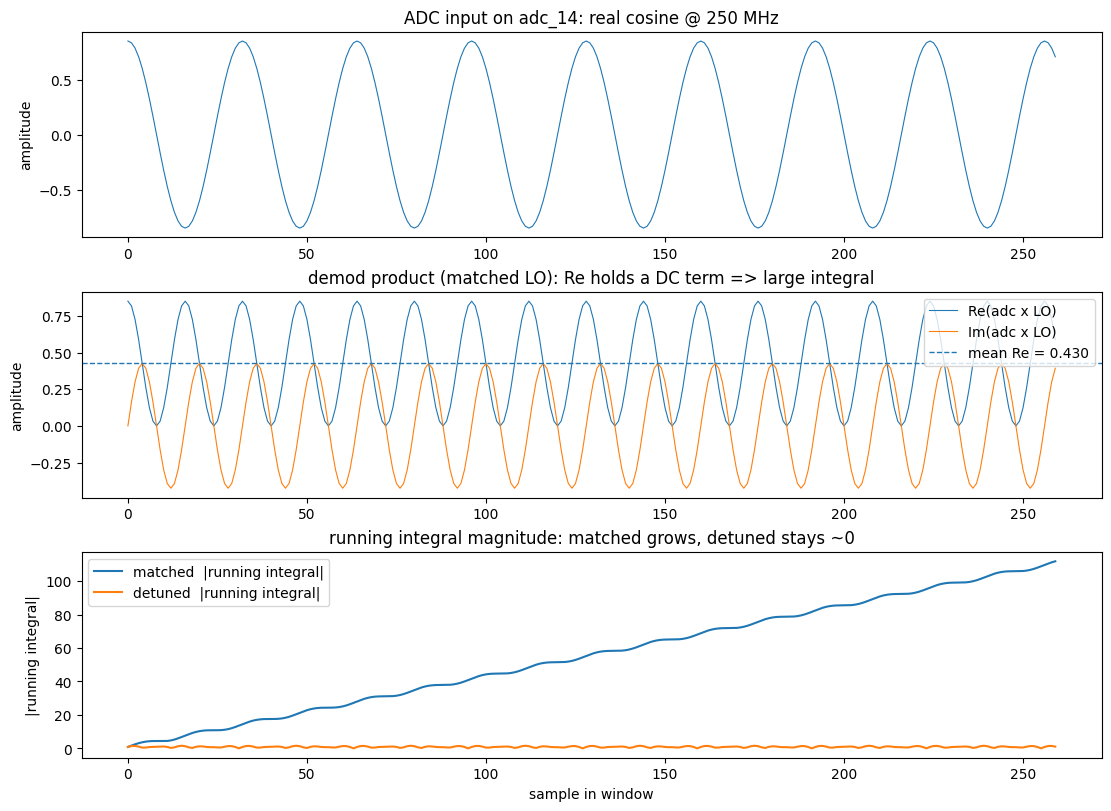

hardware |real + i*imag|  = 3,648,297
software |integral|*2^15  = 3,662,941
ratio hw/sw = 0.996   (~1 => the cosim demod path matches the software model)
detuned software |int|*2^15 = 34,595   (<< matched => frequency must match)


In [4]:
# reconstruct the ADC input + the decoder's demod product: demod[s] = adc[s] * exp(i.pi.F.s / 2^(w-1))
# at sample index s, integrated over the window (ReadoutDecoder.md S1.1). adc[s] is the very tone the
# harness injected on adc_14.
wdt = cfg.contract.data_width; nlanes = cfg.contract.adc_batch
n_int = cfg.s2batch(DUR) + 1          # the window integrates dur+1 batches
scale = float(1 << (wdt - 1))

def window(f_demod):
    Fa, Fd = cfg.freq2code(F_READOUT), cfg.freq2code(f_demod)
    s = np.arange(n_int * nlanes)
    adc = ADC_AMP * np.cos(np.pi * Fa * s / scale)
    return s, adc, adc * np.exp(1j * np.pi * Fd * s / scale)

s, adc, demod = window(F_READOUT)         # matched LO
_, _, demod_det = window(F_DETUNED)       # detuned LO (software-only contrast)

fig, ax = plt.subplots(3, 1, figsize=(11, 8), constrained_layout=True)
ax[0].plot(s, adc, lw=0.8)
ax[0].set(title=f"ADC input on adc_14: real cosine @ {F_READOUT/1e6:.0f} MHz", ylabel="amplitude")

ax[1].plot(s, demod.real, lw=0.8, label="Re(adc x LO)")
ax[1].plot(s, demod.imag, lw=0.8, label="Im(adc x LO)")
ax[1].axhline(demod.real.mean(), color="C0", ls="--", lw=1, label=f"mean Re = {demod.real.mean():.3f}")
ax[1].set(title="demod product (matched LO): Re holds a DC term => large integral", ylabel="amplitude")
ax[1].legend(loc="upper right")

ax[2].plot(np.abs(np.cumsum(demod)), label="matched  |running integral|")
ax[2].plot(np.abs(np.cumsum(demod_det)), label="detuned  |running integral|")
ax[2].set(title="running integral magnitude: matched grows, detuned stays ~0",
          xlabel="sample in window", ylabel="|running integral|")
ax[2].legend(loc="upper left")
plt.show()

# validate the software demod against the hardware integral read back over AXI (magnitude is
# phase-invariant; the absolute Re/Im split differs by a constant, magnitude-invariant offset).
sw_mag = abs(demod.sum()) * scale
hw_mag = (real ** 2 + imag ** 2) ** 0.5
print(f"hardware |real + i*imag|  = {hw_mag:,.0f}")
print(f"software |integral|*2^15  = {sw_mag:,.0f}")
print(f"ratio hw/sw = {hw_mag/sw_mag:.3f}   (~1 => the cosim demod path matches the software model)")
print(f"detuned software |int|*2^15 = {abs(demod_det.sum())*scale:,.0f}   (<< matched => frequency must match)")

**What we see.** The matched LO demodulates the ADC tone to a baseband with a DC term, so the integral
grows steadily and the hardware reports a large `|real + i·imag|` — matching the software model. A
detuned LO would integrate to ~0. This is the dispersive-readout front end exercised end-to-end:
ADC 14 → demod → integrate → read-back, all on the Verilated SoC under the production software.